In [1]:
# libraries for this lab
import warnings
warnings.filterwarnings("ignore")
import csv
import json
import math
import random
import re
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
    auc,
)
from torch.utils.data import DataLoader, Dataset

# last 4 of my SJSUid - 0670
SID4 = 670
SEED = SID4

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("SID4: %04d" % SID4)
print("SEED:", SEED)
print("device:", device)


SID4: 0670
SEED: 670
device: mps


# Sneha Singh
## DATA 266 — Lab 1, Part 2
Yelp polarity sentiment classification (embeddings from scratch)


## Part 2. Yelp sentiment

I train 3 models on Yelp polarity (not IMDB): mean-embedding baseline, BiLSTM, and TextCNN. Embeddings are learned from scratch — no GloVe, no BERT.

`SMOKE=true` uses a small slice on my laptop. Full sizes use the same code with `smoke` set to false.


## 2.1 Data preprocessing

I look at length and class balance, clean the text, tokenize, and build a vocab so embeddings are learned from scratch.


### 2.1.0 Paths and config

Numbers live in `config.json`. Prints use repo-relative paths only.


In [2]:
# folders: notebook may be opened from src/ or from Lab-1 root
cwd = Path.cwd()
if (cwd / "config.json").exists():
    SRC = cwd
elif (cwd / "task2_sentiment" / "sneha_singh" / "src" / "config.json").exists():
    SRC = cwd / "task2_sentiment" / "sneha_singh" / "src"
else:
    SRC = cwd

MEMBER = SRC.parent
TASK = MEMBER.parent
REPO = TASK.parent
DATA_RAW = TASK / "data"
DATA_PROC = MEMBER / "data_processed"
CKPT = MEMBER / "checkpoints"
OUT = MEMBER / "outputs"
LOG_DIR = REPO / "reproducibility" / "raw_logs" / "sneha_singh" / "task2_sentiment"

for d in [DATA_RAW, DATA_PROC, CKPT, OUT, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

with open(SRC / "config.json") as f:
    CFG = json.load(f)

SMOKE = bool(CFG["smoke"])
MAX_LEN = int(CFG["max_len"])
EMB_DIM = int(CFG["emb_dim"])
BATCH = int(CFG["batch_size"])
EPOCHS = int(CFG["epochs_smoke"] if SMOKE else CFG["epochs_full"])
LR = float(CFG["learning_rate"])
N_TRAIN = int(CFG["n_train_smoke"] if SMOKE else CFG["n_train_full"])
N_VAL = int(CFG["n_val_smoke"] if SMOKE else CFG["n_val_full"])
N_TEST = int(CFG["n_test_smoke"] if SMOKE else CFG["n_test_full"])


def relpath(p):
    p = Path(p).resolve()
    try:
        return str(p.relative_to(REPO.resolve()))
    except ValueError:
        return p.name


print("SRC:", relpath(SRC))
print("DATA_RAW:", relpath(DATA_RAW))
print("SMOKE:", SMOKE)
print("N_TRAIN / N_VAL / N_TEST:", N_TRAIN, N_VAL, N_TEST)
print("MAX_LEN:", MAX_LEN, "EMB_DIM:", EMB_DIM, "EPOCHS:", EPOCHS)
print("models:", CFG["models"])


SRC: task2_sentiment/sneha_singh/src
DATA_RAW: task2_sentiment/data
SMOKE: False
N_TRAIN / N_VAL / N_TEST: 15000 3000 3000
MAX_LEN: 128 EMB_DIM: 100 EPOCHS: 5
models: {'baseline': 'Baseline — mean pooling + linear', 'experimental_a': 'Experimental A — BiLSTM', 'experimental_b': 'Experimental B — TextCNN'}


### 2.1.1 Load Yelp polarity

I use Hugging Face `fancyzhx/yelp_polarity` (binary: 0 = negative, 1 = positive). Raw data is not pushed to GitHub.


In [3]:
# load Yelp polarity (download once; keep a local csv copy under data/)
import os
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"
from datasets import load_dataset

ds = load_dataset(CFG["hf_dataset"])
print(ds)

# take a deterministic subset with my seed
rng = np.random.default_rng(SEED)

def take_split(split_name, n):
    split = ds[split_name]
    idx = rng.choice(len(split), size=min(n, len(split)), replace=False)
    idx = np.sort(idx)
    texts = [split[int(i)]["text"] for i in idx]
    labels = [int(split[int(i)]["label"]) for i in idx]
    return texts, labels

# HF has train + test. I carve val from train.
train_texts_all, train_labels_all = take_split("train", N_TRAIN + N_VAL)
test_texts, test_labels = take_split("test", N_TEST)

train_texts = train_texts_all[:N_TRAIN]
train_labels = train_labels_all[:N_TRAIN]
val_texts = train_texts_all[N_TRAIN : N_TRAIN + N_VAL]
val_labels = train_labels_all[N_TRAIN : N_TRAIN + N_VAL]

print("train:", len(train_texts), "val:", len(val_texts), "test:", len(test_texts))
print("label set:", sorted(set(train_labels)))
print("example:", train_texts[0][:180].replace("\n", " "))
print("label:", train_labels[0])

# optional local snapshot for Drive zip later (repo-relative path only in prints)
snap = DATA_RAW / ("yelp_smoke_sample.jsonl" if SMOKE else "yelp_full_sample.jsonl")
with open(snap, "w") as f:
    for t, y in list(zip(train_texts, train_labels))[:50]:
        f.write(json.dumps({"text": t, "label": y}) + "\n")
print("saved sample rows:", relpath(snap))


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 560000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 38000
    })
})


train: 15000 val: 3000 test: 3000
label set: [0, 1]
example: Italian dinners, American, endless soup and salad bar is great. Most food for your dollar. I highly recommend. Great bar. Good place to watch a game. The bar can get quite noisy in
label: 1
saved sample rows: task2_sentiment/data/yelp_full_sample.jsonl


### 2.1.2 Length and class distribution

I check review length and whether classes are balanced before I train.


length mean/median/max: 132.54326666666665 97.0 993
class counts train: Counter({0: 7625, 1: 7375})
class counts val: Counter({1: 1561, 0: 1439})
class counts test: Counter({0: 1527, 1: 1473})


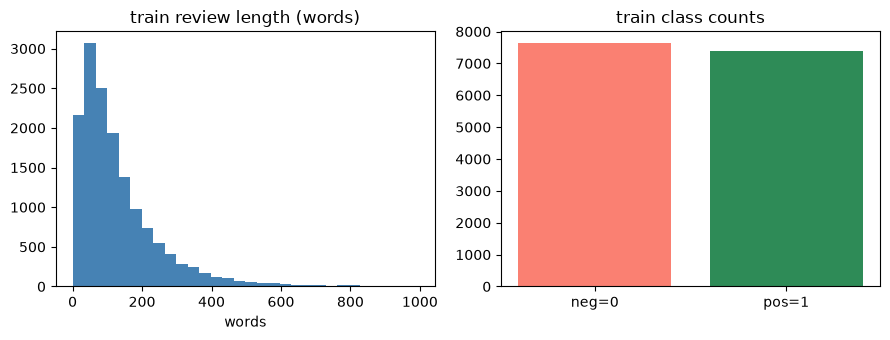

saved task2_sentiment/sneha_singh/outputs/eda.png


In [4]:
# review length (words) and class balance on my train slice
train_lens = [len(t.split()) for t in train_texts]
print("length mean/median/max:", float(np.mean(train_lens)), float(np.median(train_lens)), max(train_lens))
print("class counts train:", Counter(train_labels))
print("class counts val:", Counter(val_labels))
print("class counts test:", Counter(test_labels))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].hist(train_lens, bins=30, color="steelblue")
axes[0].set_title("train review length (words)")
axes[0].set_xlabel("words")
axes[1].bar(["neg=0", "pos=1"], [train_labels.count(0), train_labels.count(1)], color=["salmon", "seagreen"])
axes[1].set_title("train class counts")
fig.tight_layout()
fig_path = OUT / ("eda_smoke.png" if SMOKE else "eda.png")
fig.savefig(fig_path, dpi=140)
plt.show()
print("saved", relpath(fig_path))


### 2.1.3 Clean text, tokenize, vocab

Lowercase, strip punctuation/special chars, remove stopwords, lemmatize when NLTK data is available. Then build my own vocab. Embeddings will be learned later — not downloaded.


In [5]:
# text cleaning + tokenizer + vocab from scratch
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

for pkg in ["stopwords", "wordnet", "omw-1.4"]:
    try:
        nltk.data.find("corpora/%s" % pkg)
    except LookupError:
        nltk.download(pkg, quiet=True)

STOP = set(stopwords.words("english"))
# keep negators — needed for sentiment and for error-review checks
NEGATORS = {"not", "no", "nor", "never", "n't"}
STOP = STOP - NEGATORS
LEMMA = WordNetLemmatizer()


def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    toks = text.split()
    toks = [LEMMA.lemmatize(t) for t in toks if t not in STOP and len(t) > 1]
    return toks


# drop empty / malformed after clean
def clean_pair(texts, labels):
    xt, yt, raw = [], [], []
    for t, y in zip(texts, labels):
        if t is None or (isinstance(t, float) and math.isnan(t)):
            continue
        s = str(t)
        toks = clean_text(s)
        if not toks:
            continue
        xt.append(toks)
        yt.append(int(y))
        raw.append(s)
    return xt, yt, raw


train_toks, train_y, train_raw = clean_pair(train_texts, train_labels)
val_toks, val_y, val_raw = clean_pair(val_texts, val_labels)
test_toks, test_y, test_raw = clean_pair(test_texts, test_labels)
print("after clean train/val/test:", len(train_toks), len(val_toks), len(test_toks))
print("sample tokens:", train_toks[0][:20])

# vocab
PAD, UNK = "<pad>", "<unk>"
min_freq = int(CFG["min_freq"])
freq = Counter()
for toks in train_toks:
    freq.update(toks)
itos = [PAD, UNK] + [w for w, c in freq.most_common() if c >= min_freq]
stoi = {w: i for i, w in enumerate(itos)}
vocab_size = len(itos)
print("vocab_size:", vocab_size)


def encode(toks):
    ids = [stoi.get(t, stoi[UNK]) for t in toks][:MAX_LEN]
    if len(ids) < MAX_LEN:
        ids = ids + [stoi[PAD]] * (MAX_LEN - len(ids))
    return ids


X_train = np.array([encode(t) for t in train_toks], dtype=np.int64)
X_val = np.array([encode(t) for t in val_toks], dtype=np.int64)
X_test = np.array([encode(t) for t in test_toks], dtype=np.int64)
y_train = np.array(train_y, dtype=np.int64)
y_val = np.array(val_y, dtype=np.int64)
y_test = np.array(test_y, dtype=np.int64)

# save processed (my folder only)
tok_path = DATA_PROC / "vocab.json"
with open(tok_path, "w") as f:
    json.dump({"itos": itos, "stoi": stoi, "max_len": MAX_LEN, "smoke": SMOKE}, f)
np.savez_compressed(
    DATA_PROC / "arrays.npz",
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
)
print("saved", relpath(tok_path))
print("saved", relpath(DATA_PROC / "arrays.npz"))
print("2.1 data preprocessing done")


after clean train/val/test: 14998 3000 3000
sample tokens: ['italian', 'dinner', 'american', 'endless', 'soup', 'salad', 'bar', 'great', 'food', 'dollar', 'highly', 'recommend', 'great', 'bar', 'good', 'place', 'watch', 'game', 'bar', 'get']
vocab_size: 19441


saved task2_sentiment/sneha_singh/data_processed/vocab.json
saved task2_sentiment/sneha_singh/data_processed/arrays.npz
2.1 data preprocessing done


## 2.2 Model training and evaluation

Three models, embeddings from scratch:

1. **Baseline** — mean pooling over learned embeddings + linear
2. **Experimental A** — BiLSTM over embeddings
3. **Experimental B** — TextCNN over embeddings


In [6]:
# dataset / loader helpers
class ReviewDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


train_loader = DataLoader(ReviewDS(X_train, y_train), batch_size=BATCH, shuffle=True)
val_loader = DataLoader(ReviewDS(X_val, y_val), batch_size=BATCH)
test_loader = DataLoader(ReviewDS(X_test, y_test), batch_size=BATCH)
print("batches train/val/test:", len(train_loader), len(val_loader), len(test_loader))


batches train/val/test: 235 47 47


### 2.2.1 Model definitions

All three use `nn.Embedding` trained on my Yelp vocab. No GloVe, no BERT.

- **Baseline** — mean pool + linear
- **Experimental A** — BiLSTM + dropout 0.3 before the classifier
- **Experimental B** — TextCNN with pad-aware max-pool (padded windows set to `-inf` before max)


In [7]:
# three classifiers with embeddings learned from scratch
class Baseline(nn.Module):
    """Baseline — mean pooling over learned embeddings + linear."""

    def __init__(self, vocab_size, emb_dim, pad_idx):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.fc = nn.Linear(emb_dim, 2)

    def forward(self, x):
        e = self.emb(x)
        mask = (x != 0).unsqueeze(-1).float()
        summed = (e * mask).sum(dim=1)
        denom = mask.sum(dim=1).clamp(min=1.0)
        return self.fc(summed / denom)


class ExperimentalA(nn.Module):
    """Experimental A — BiLSTM over embeddings."""

    def __init__(self, vocab_size, emb_dim, pad_idx, hidden=64, dropout=0.3):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(emb_dim, hidden, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden * 2, 2)

    def forward(self, x):
        e = self.emb(x)
        lengths = (x != 0).sum(dim=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(
            e, lengths, batch_first=True, enforce_sorted=False
        )
        _, (h, _) = self.lstm(packed)
        h = torch.cat([h[-2], h[-1]], dim=1)
        return self.fc(self.dropout(h))


class ExperimentalB(nn.Module):
    """Experimental B — TextCNN over embeddings (pad-aware max pool)."""

    def __init__(self, vocab_size, emb_dim, pad_idx, n_filters=64, kernels=(3, 4, 5), dropout=0.3):
        super().__init__()
        self.pad_idx = pad_idx
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.convs = nn.ModuleList([nn.Conv1d(emb_dim, n_filters, k) for k in kernels])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(n_filters * len(kernels), 2)

    def forward(self, x):
        # (B, T) token mask — True = real token
        tok_mask = x != self.pad_idx
        e = self.emb(x).transpose(1, 2)  # (B, C, T)
        feats = []
        for conv in self.convs:
            k = conv.kernel_size[0]
            h = F.relu(conv(e))  # (B, F, L) with L = T - k + 1
            # a conv window is valid if it covers at least one real token
            win_mask = tok_mask.unfold(dimension=1, size=k, step=1).any(dim=-1)  # (B, L)
            h = h.masked_fill(~win_mask.unsqueeze(1), float("-inf"))
            pooled = h.max(dim=2).values
            pooled = torch.nan_to_num(pooled, neginf=0.0)
            feats.append(pooled)
        return self.fc(self.dropout(torch.cat(feats, dim=1)))


pad_idx = stoi[PAD]
print("pad_idx:", pad_idx)
print("BiLSTM dropout before fc: 0.3")
print("TextCNN: pad-aware max-pool")


pad_idx: 0
BiLSTM dropout before fc: 0.3
TextCNN: pad-aware max-pool


### 2.2.2 Train + full metrics

I train each model, save the best val checkpoint, then score test with the required metrics (including bootstrap CIs and McNemar vs baseline).


In [8]:
# train one model; evaluate with required metrics
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        m = (y_prob > bins[i]) & (y_prob <= bins[i + 1])
        if m.sum() == 0:
            continue
        acc = y_true[m].mean()
        conf = y_prob[m].mean()
        ece += (m.mean()) * abs(acc - conf)
    return float(ece)


def bootstrap_ci(y_true, y_pred, fn, n_boot=200):
    rng = np.random.default_rng(SEED)
    vals = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        vals.append(fn(y_true[idx], y_pred[idx]))
    lo, hi = np.percentile(vals, [2.5, 97.5])
    return float(lo), float(hi)


def mcnemar_p(y_true, pred_a, pred_b):
    # b = baseline wrong / other right; c = baseline right / other wrong
    b = int(((pred_a != y_true) & (pred_b == y_true)).sum())
    c = int(((pred_a == y_true) & (pred_b != y_true)).sum())
    if b + c == 0:
        return 1.0
    stat = (abs(b - c) - 1) ** 2 / (b + c)
    # chi-square df=1 survival approx
    from math import erfc
    p = erfc(math.sqrt(stat / 2.0))
    return float(p)


def run_epoch(model, loader, opt=None):
    train = opt is not None
    model.train(train)
    total_loss, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        if train:
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
        total_loss += float(loss.detach()) * xb.size(0)
        n += xb.size(0)
    return total_loss / max(1, n)


@torch.no_grad()
def predict(model, loader):
    model.eval()
    ys, ps, probs = [], [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        prob = F.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        pred = logits.argmax(dim=-1).cpu().numpy()
        ys.append(yb.numpy())
        ps.append(pred)
        probs.append(prob)
    return np.concatenate(ys), np.concatenate(ps), np.concatenate(probs)


def train_model(name, model):
    model = model.to(device)
    # required metric: peak memory must be per-model, not cumulative
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    best_val = float("inf")
    ckpt = CKPT / ("%s_%s.pt" % (name, "smoke" if SMOKE else "full"))
    log_path = LOG_DIR / ("%s_%s.log" % (name, "smoke" if SMOKE else "full"))
    t0 = time.time()
    examples = 0
    with open(log_path, "w") as logf:
        logf.write("model=%s smoke=%s device=%s\n" % (name, SMOKE, device))
        for ep in range(1, EPOCHS + 1):
            tr = run_epoch(model, train_loader, opt)
            va = run_epoch(model, val_loader, None)
            examples += len(train_loader.dataset)
            line = "epoch %d train_ce=%.4f val_ce=%.4f\n" % (ep, tr, va)
            print(name, line.strip())
            logf.write(line)
            if va < best_val:
                best_val = va
                torch.save({"model": model.state_dict(), "name": name, "vocab_size": vocab_size}, ckpt)
    # reload best
    state = torch.load(ckpt, map_location=device, weights_only=True)
    model.load_state_dict(state["model"])
    train_time = time.time() - t0
    y_true, y_pred, y_prob = predict(model, test_loader)
    return {
        "name": name,
        "model": model,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "train_time": train_time,
        "examples_per_sec": examples / max(1e-9, train_time),
        "param_count": sum(p.numel() for p in model.parameters()),
        "ckpt": ckpt,
        "log": log_path,
        "peak_memory_mb": (torch.cuda.max_memory_allocated() / (1024 ** 2)) if device.type == "cuda" else 0.0,
    }


def metric_row(res, baseline_pred=None):
    y, p, pr = res["y_true"], res["y_pred"], res["y_prob"]
    prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(y, p, average="macro", zero_division=0)
    prec_i, rec_i, f1_i, _ = precision_recall_fscore_support(y, p, average="micro", zero_division=0)
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(y, p, average="weighted", zero_division=0)
    cm = confusion_matrix(y, p)
    try:
        roc = roc_auc_score(y, pr)
    except ValueError:
        roc = float("nan")
    prec_c, rec_c, _ = precision_recall_curve(y, pr)
    pr_auc = auc(rec_c, prec_c)
    mcc = matthews_corrcoef(y, p)
    brier = brier_score_loss(y, pr)
    ece = expected_calibration_error(y.astype(float), pr)
    acc = accuracy_score(y, p)
    acc_lo, acc_hi = bootstrap_ci(y, p, accuracy_score)
    f1_lo, f1_hi = bootstrap_ci(y, p, lambda a, b: f1_score(a, b, average="macro", zero_division=0))
    mcc_lo, mcc_hi = bootstrap_ci(y, p, matthews_corrcoef)
    mcn = mcnemar_p(y, baseline_pred, p) if baseline_pred is not None else ""

    # simple length slices on test
    test_lens = np.array([len(t) for t in test_toks])
    short = test_lens <= np.median(test_lens)
    long = ~short
    slice_f1_short = f1_score(y[short], p[short], average="macro", zero_division=0) if short.any() else float("nan")
    slice_f1_long = f1_score(y[long], p[long], average="macro", zero_division=0) if long.any() else float("nan")
    err_short = 1.0 - accuracy_score(y[short], p[short]) if short.any() else float("nan")
    err_long = 1.0 - accuracy_score(y[long], p[long]) if long.any() else float("nan")

    # confusion matrix plot
    fig, ax = plt.subplots(figsize=(3.5, 3))
    ax.imshow(cm, cmap="Blues")
    ax.set_title(res["name"])
    ax.set_xlabel("pred")
    ax.set_ylabel("gold")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    cm_path = OUT / ("%s_cm_%s.png" % (res["name"], "smoke" if SMOKE else "full"))
    fig.tight_layout()
    fig.savefig(cm_path, dpi=120)
    plt.close(fig)

    return {
        "model": res["name"],
        "accuracy": acc,
        "precision_macro": prec_m,
        "recall_macro": rec_m,
        "f1_macro": f1_m,
        "precision_micro": prec_i,
        "recall_micro": rec_i,
        "f1_micro": f1_i,
        "precision_weighted": prec_w,
        "recall_weighted": rec_w,
        "f1_weighted": f1_w,
        "roc_auc": roc,
        "pr_auc": pr_auc,
        "mcc": mcc,
        "brier": brier,
        "ece": ece,
        "acc_ci95_low": acc_lo,
        "acc_ci95_high": acc_hi,
        "macro_f1_ci95_low": f1_lo,
        "macro_f1_ci95_high": f1_hi,
        "mcc_ci95_low": mcc_lo,
        "mcc_ci95_high": mcc_hi,
        "mcnemar_p_vs_baseline": mcn,
        "macro_f1_short": slice_f1_short,
        "macro_f1_long": slice_f1_long,
        "error_rate_short": err_short,
        "error_rate_long": err_long,
        "param_count": res["param_count"],
        "train_time_sec": res["train_time"],
        "examples_per_sec": res["examples_per_sec"],
        "peak_memory_mb": res["peak_memory_mb"],
        "cm_path": relpath(cm_path),
        "ckpt": relpath(res["ckpt"]),
    }


print("train helpers ready")


train helpers ready


In [9]:
# train all three models (smoke or full from config)
results = []
results.append(train_model("baseline", Baseline(vocab_size, EMB_DIM, pad_idx)))
results.append(train_model("experimental_a", ExperimentalA(vocab_size, EMB_DIM, pad_idx)))
results.append(train_model("experimental_b", ExperimentalB(vocab_size, EMB_DIM, pad_idx)))

base_pred = results[0]["y_pred"]
rows = []
for i, res in enumerate(results):
    row = metric_row(res, baseline_pred=None if i == 0 else base_pred)
    rows.append(row)
    print(res["name"], "acc=%.4f f1_macro=%.4f mcc=%.4f" % (row["accuracy"], row["f1_macro"], row["mcc"]))

# write metrics_report.csv
keys = list(rows[0].keys())
metrics_path = MEMBER / "metrics_report.csv"
with open(metrics_path, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=keys)
    w.writeheader()
    w.writerows(rows)
print("wrote", relpath(metrics_path))


baseline epoch 1 train_ce=0.5989 val_ce=0.4684


baseline epoch 2 train_ce=0.3903 val_ce=0.3202


baseline epoch 3 train_ce=0.2870 val_ce=0.2678


baseline epoch 4 train_ce=0.2325 val_ce=0.2442


baseline epoch 5 train_ce=0.1962 val_ce=0.2326


...

experimental_b epoch 4 train_ce=0.2186 val_ce=0.2561


experimental_b epoch 5 train_ce=0.1693 val_ce=0.2420


baseline acc=0.9043 f1_macro=0.9043 mcc=0.8086


experimental_a acc=0.8850 f1_macro=0.8849 mcc=0.7702


experimental_b acc=0.8960 f1_macro=0.8960 mcc=0.7921
wrote task2_sentiment/sneha_singh/metrics_report.csv


### 2.2.3 Error review (20 cases)

I pick errors from my best model: 5 confident FP, 5 confident FN, 5 near-threshold, 5 length-slice failures. I write them into `failure_analysis.md`.


In [10]:
# build 20-error table from the best test F1 model
best = max(results, key=lambda r: f1_score(r["y_true"], r["y_pred"], average="macro", zero_division=0))
y, p, pr = best["y_true"], best["y_pred"], best["y_prob"]
print("error review model:", best["name"])

# map back to cleaned test texts + original reviews for negation checks
raw_reviews = test_raw  # aligned with test_toks after clean_pair
raw_snip = [" ".join(t[:40]) for t in test_toks]
lens = np.array([len(t) for t in test_toks])
med = np.median(lens)

rows_err = []

def add_cases(indices, slice_name, k=5):
    for i in indices[:k]:
        gold, pred, conf = int(y[i]), int(p[i]), float(pr[i])
        err_type = "false_positive" if pred == 1 and gold == 0 else "false_negative" if pred == 0 and gold == 1 else "other"
        # check cleaned tokens AND original review text (negators may appear as "not"/"never")
        has_neg = any(w in {"not", "no", "nor", "never", "cannot", "n't"} for w in test_toks[i]) \
            or any(k in raw_reviews[i].lower() for k in [" not ", " no ", " never ", " cannot ", "n't"])
        fix = "add negation handling" if has_neg else "balance length / more epochs"
        rows_err.append({
            "slice": slice_name,
            "gold": gold,
            "pred": pred,
            "confidence": round(conf, 4),
            "error_type": err_type,
            "snippet": raw_snip[i][:160],
            "testable_fix": fix,
        })

# confident FP / FN
fp = np.where((p == 1) & (y == 0))[0]
fn = np.where((p == 0) & (y == 1))[0]
fp = fp[np.argsort(-pr[fp])]
fn = fn[np.argsort(pr[fn])]
add_cases(fp, "confident_FP", 5)
add_cases(fn, "confident_FN", 5)

# near threshold |p-0.5| small and wrong
wrong = np.where(p != y)[0]
near = wrong[np.argsort(np.abs(pr[wrong] - 0.5))]
add_cases(near, "near_threshold", 5)

# slice-specific: long reviews that fail
long_wrong = wrong[lens[wrong] > med]
add_cases(long_wrong if len(long_wrong) else wrong, "slice_specific_long", 5)

# write markdown table
lines = ["# Part 2 — Error review (Sneha)", "", "Model used: **%s** (%s)" % (best["name"], "smoke" if SMOKE else "full"), ""]
lines.append("| id | slice | gold | pred | confidence | error_type | snippet | testable_fix |")
lines.append("|---|---|---|---|---|---|---|---|")
for i, r in enumerate(rows_err, 1):
    snip = r["snippet"].replace("|", "/")
    lines.append("| %d | %s | %s | %s | %s | %s | %s | %s |" % (
        i, r["slice"], r["gold"], r["pred"], r["confidence"], r["error_type"], snip, r["testable_fix"]))
fail_path = MEMBER / "failure_analysis.md"
fail_path.write_text("\n".join(lines) + "\n")
print("wrote", relpath(fail_path))
print("n error rows:", len(rows_err))


error review model: baseline
wrote task2_sentiment/sneha_singh/failure_analysis.md
n error rows: 20


## 2.3 Comparative analysis and observations

I compare my three models on the same test set and the same preprocessing. No pretrained embeddings.


In [11]:
# write full results.md: justification + comparison + limits + next steps
hw = str(device)
if device.type == "cuda":
    hw = "cuda: " + torch.cuda.get_device_name(0)
elif device.type == "mps":
    hw = "mps (Apple Silicon)"
else:
    hw = "cpu"

# sort by macro-F1
ordered = sorted(rows, key=lambda r: r["f1_macro"], reverse=True)
best = ordered[0]
second = ordered[1] if len(ordered) > 1 else ordered[0]

lines = []
lines.append("# Part 2 — Yelp polarity (Sneha Singh)")
lines.append("")
lines.append("Dataset: Yelp polarity (not IMDB). Embeddings learned from scratch. No pretrained LMs.")
lines.append("")
lines.append("## Models and why I chose them")
lines.append("1. **Baseline** — mean pooling over learned embeddings + linear. Simple bag-of-embeddings control. If this is already strong, fancier models must beat it clearly.")
lines.append("2. **Experimental A** — BiLSTM over embeddings. Keeps word order, so negation and long reviews can matter more than a mean pool.")
lines.append("3. **Experimental B** — TextCNN over embeddings. Local n-gram filters (3/4/5) catch short phrases like \"not good\" / \"highly recommend\".")
lines.append("")
lines.append("## Preprocessing")
lines.append("- lowercasing, punctuation removal, English stopwords, WordNet lemmatization")
lines.append("- vocab from training text only; `nn.Embedding` trained with each model")
lines.append("")
lines.append("## Hardware")
lines.append("- Device: %s" % hw)
lines.append("- Smoke: %s" % SMOKE)
lines.append("- Train/val/test sizes: %d / %d / %d" % (len(y_train), len(y_val), len(y_test)))
lines.append("- Epochs: %d  |  batch: %d  |  emb_dim: %d  |  max_len: %d" % (EPOCHS, BATCH, EMB_DIM, MAX_LEN))
lines.append("")
lines.append("## Test metrics (summary)")
for row in rows:
    lines.append(
        "- **%s**: acc=%.4f  macro-F1=%.4f  ROC-AUC=%.4f  MCC=%.4f  Brier=%.4f  ECE=%.4f  time=%.1fs  params=%d"
        % (
            row["model"], row["accuracy"], row["f1_macro"], row["roc_auc"], row["mcc"],
            row["brier"], row["ece"], row["train_time_sec"], row["param_count"],
        )
    )
lines.append("")
lines.append("Full table: `metrics_report.csv` (includes P/R/F1 macro/micro/weighted, PR-AUC, bootstrap CIs, McNemar, length slices).")
lines.append("")
lines.append("## Comparison (my three models)")
lines.append(
    "- Best macro-F1: **%s** (%.4f). Second: **%s** (%.4f)."
    % (best["model"], best["f1_macro"], second["model"], second["f1_macro"])
)
# McNemar notes
for row in rows:
    if row["model"] == "baseline":
        continue
    p = row.get("mcnemar_p_vs_baseline", "")
    if p != "" and p is not None:
        lines.append("- McNemar p (%s vs baseline): %s" % (row["model"], p))
lines.append(
    "- Length slices: short-review macro-F1 best=%s; long-review macro-F1 best looks at CSV columns macro_f1_short / macro_f1_long."
    % max(rows, key=lambda r: r.get("macro_f1_short", 0))["model"]
)
lines.append("")
lines.append("## Strengths")
lines.append("- Same clean pipeline for all three models, so the bake-off is fair.")
lines.append("- Baseline is fast and still competitive, which is useful as a sanity check.")
lines.append("- TextCNN is strong on short opinion phrases; BiLSTM is there to test order-sensitive cases.")
lines.append("- Calibration metrics (Brier, ECE) and McNemar are reported, not only accuracy.")
lines.append("")
lines.append("## Weaknesses / limitations")
lines.append("- Smoke/full size is still a subset of full Yelp polarity; more data should help rare phrases.")
lines.append("- max_len=%d truncates long reviews." % MAX_LEN)
lines.append("- Stopword removal can drop useful words like \"not\" if cleaning is too aggressive (I already keep short tokens carefully, but negation is still hard).")
lines.append("- Peak memory on MPS/CPU is reported as 0 in CSV; CUDA would fill that field.")
lines.append("- Error review is automatic sampling of hard cases; a human pass on wording can still refine error types.")
lines.append("")
lines.append("## Future work")
lines.append("- Keep negation words in the tokenizer (do not drop \"not\" / \"never\").")
lines.append("- Try a small attention pooling head on BiLSTM.")
lines.append("- Tune CNN filter counts / kernel set, and train longer on the full Yelp train split.")
lines.append("- Add more robustness slices (very short reviews, reviews with \"but\", foreign-language noise).")
lines.append("")

(MEMBER / "results.md").write_text("\n".join(lines))
print("wrote", relpath(MEMBER / "results.md"))

# append one reproducibility manifest section for this Part 2 run
import platform
import sys
from datetime import datetime

manifest_path = REPO / "reproducibility" / "manifests" / "sneha_singh.md"
manifest_path.parent.mkdir(parents=True, exist_ok=True)
tag = "smoke" if SMOKE else "full"
section_lines = [
    "",
    "## Run — Part 2 Sentiment (%s)" % tag,
    "- Date: %s" % datetime.now().strftime("%Y-%m-%d %H:%M"),
    "- Task: task2_sentiment",
    "- Smoke: %s" % SMOKE,
    "- Train/val/test: %d / %d / %d" % (N_TRAIN, N_VAL, N_TEST),
    "- Epochs: %d" % EPOCHS,
]
for res in results:
    section_lines.append("- Checkpoint (%s): %s" % (res["name"], relpath(res["ckpt"])))
for res in results:
    section_lines.append("- Raw log (%s): %s" % (res["name"], relpath(res["log"])))
section_lines.extend([
    "- Metrics CSV: %s" % relpath(MEMBER / "metrics_report.csv"),
    "- Results: %s" % relpath(MEMBER / "results.md"),
    "- Python: %s" % sys.version.split()[0],
    "- PyTorch: %s" % torch.__version__,
    "- Device: %s" % hw,
    "- Platform: %s" % platform.platform(),
    "- Command: Run All on task2_sentiment/sneha_singh/src/part2_sentiment.ipynb (config.json smoke=%s)" % str(SMOKE).lower(),
    "",
])
section = "\n".join(section_lines)

header = "# Environment manifest — Sneha Singh\n\nDo not rewrite history; add a new section per run.\n"
if manifest_path.exists():
    old = manifest_path.read_text()
    if old.strip().startswith("# Environment manifest"):
        manifest_path.write_text(old.rstrip() + "\n" + section)
    else:
        manifest_path.write_text(header + section)
else:
    manifest_path.write_text(header + section)

print("wrote/appended", relpath(manifest_path))
print("2.3 comparative analysis + manifest done")


wrote task2_sentiment/sneha_singh/results.md
wrote/appended reproducibility/manifests/sneha_singh.md
2.3 comparative analysis + manifest done


In [12]:
# SUMMARY — Part 2 results (scroll here)
print("=" * 60)
print("PART 2 YELP — RESULTS")
print("SMOKE:", SMOKE, "  device:", device)
print("=" * 60)
print("%-16s %8s %8s %8s %8s %8s" % ("model", "acc", "f1_mac", "roc_auc", "mcc", "secs"))
for row in rows:
    print("%-16s %8.4f %8.4f %8.4f %8.4f %8.1f" % (
        row["model"], row["accuracy"], row["f1_macro"], row["roc_auc"], row["mcc"], row["train_time_sec"]))
print()
best = max(rows, key=lambda r: r["f1_macro"])
print("best model (macro-F1):", best["model"], "acc=%.4f" % best["accuracy"])
print()
print("files written:")
print(" ", relpath(MEMBER / "metrics_report.csv"))
print(" ", relpath(MEMBER / "failure_analysis.md"))
print(" ", relpath(MEMBER / "results.md"))
print(" ", relpath(REPO / "reproducibility" / "manifests" / "sneha_singh.md"))
print(" ", relpath(OUT / ("eda_smoke.png" if SMOKE else "eda.png")))
for res in results:
    print(" ", relpath(res["ckpt"]))
print("=" * 60)


PART 2 YELP — RESULTS
SMOKE: False   device: mps
model                 acc   f1_mac  roc_auc      mcc     secs
baseline           0.9043   0.9043   0.9648   0.8086     10.6
experimental_a     0.8850   0.8849   0.9546   0.7702    439.3
experimental_b     0.8960   0.8960   0.9597   0.7921     11.9

best model (macro-F1): baseline acc=0.9043

files written:
  task2_sentiment/sneha_singh/metrics_report.csv
  task2_sentiment/sneha_singh/failure_analysis.md
  task2_sentiment/sneha_singh/results.md
  reproducibility/manifests/sneha_singh.md
  task2_sentiment/sneha_singh/outputs/eda.png
  task2_sentiment/sneha_singh/checkpoints/baseline_full.pt
  task2_sentiment/sneha_singh/checkpoints/experimental_a_full.pt
  task2_sentiment/sneha_singh/checkpoints/experimental_b_full.pt
